# Drainage context

This notebook generates Figure S4.

In [2]:

import glob, datetime

import geopandas as gpd
import pandas as pd
import rioxarray as rxr
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from datetime import datetime

from funcs import add_panel_label

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 8
plt.rcParams['mathtext.fontset'] = 'cm' 

%matplotlib widget


In [3]:

# Load datasets

# Vector outlines of crevasse fields and lakes
crevs_ponded = gpd.read_file('../data/outlines/pondedcrevassefields.gpkg')
lakes = gpd.read_file('../data/outlines/lakefields.gpkg')
crevs_empty = gpd.read_file('../data/outlines/emptycrevassefields.gpkg')

# Parse dates
crevs_ponded['2019_max_water'] = pd.to_datetime(crevs_ponded['2019_max_water'])
lakes['2019_max_water'] = pd.to_datetime(lakes['2019_max_water'])

# ArcticDEM msoaic (ellipsoidal height)
dem = rxr.open_rasterio('../data/dem/store_arcticdem_mosaic_32m_cog.tif').squeeze()

# Strain rates
e1 = rxr.open_rasterio('../data/velocity/ITS_LIVE_mosaic_120m_e1.tif').squeeze().rio.write_crs(3413)
e2 = rxr.open_rasterio('../data/velocity/ITS_LIVE_mosaic_120m_e2.tif').squeeze().rio.write_crs(3413)
elon = rxr.open_rasterio('../data/velocity/ITS_LIVE_mosaic_120m_elon.tif').squeeze().rio.write_crs(3413)


In [4]:
# Note number of times crevasse fields were identified under various circumstances
df = crevs_ponded
print(len(df))
print(len(df[df['valid']==True]))
print(len(df[(df['valid']==True) & (df['2019_drainage']==True)]))
print(len(df[(df['valid']==True) & (df['2019_drainage']==True) & (df['2019_multiple_maxima']=='True')]))
print(len(df[(df['valid']==True) & (df['2019_drainage']==True) & (df['2019_maxima_melt_coincidence']==True)]))

55
48
40
4
3


In [5]:
# Note number of times lakes were identified under various circumstances
df = lakes
print(len(df))
print(len(df[df['valid']==True]))
print(len(df[(df['valid']==True) & (df['2019_drainage']==True)]))
print(len(df[(df['valid']==True) & (df['2019_drainage']==True) & (df['2019_multiple_maxima']=='True')]))
print(len(df[(df['valid']==True) & (df['2019_drainage']==True) & (df['2019_maxima_melt_coincidence']==True)]))

68
52
20
2
2


In [6]:
# Filter to drainages
crevs_ponded = crevs_ponded[(crevs_ponded['valid'] == True) & (crevs_ponded['2019_drainage']==True)]
lakes = lakes[(lakes['valid']==True) & (lakes['2019_rapid_drainage']==1.0)]


## Get average raster values within each polygon

In [7]:

def zonal_mean(gdf, rxda, colname):
    means = []
    for geom in gdf.geometry:
        clipped = rxda.rio.clip([geom], gdf.crs, drop=True)
        clipped = clipped.where(clipped != -9999)  # mask nodata
        mean = float(clipped.mean().values)
        means.append(mean)
    gdf[colname] = means
    return gdf

crevs_ponded = zonal_mean(crevs_ponded, dem, "mean_h")
crevs_ponded = zonal_mean(crevs_ponded, e1, "mean_e1")
crevs_ponded = zonal_mean(crevs_ponded, e2, "mean_e2")
crevs_ponded = zonal_mean(crevs_ponded, elon, "mean_elon")

lakes = zonal_mean(lakes, dem, "mean_h")
lakes = zonal_mean(lakes, e1, "mean_e1")
lakes = zonal_mean(lakes, e2, "mean_e2")
lakes = zonal_mean(lakes, elon, "mean_elon")

crevs_empty = zonal_mean(crevs_empty, e1, "mean_e1")
crevs_empty = zonal_mean(crevs_empty, e2, "mean_e2")
crevs_empty = zonal_mean(crevs_empty, elon, "mean_elon")



/Users/tom/mambaforge/envs/geospatial/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/tom/mambaforge/envs/geospatial/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/tom/mambaforge/envs/geospatial/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a c

## Get first date of drainage of each polygon

In [8]:
def get_first_drainage(gdf, data_directory='pondedcrev'):

    labels = gdf.label.values

    earliest_melt = []
    
    for l in labels:

        # print(l)
        fpath = f'../data/timeseries/{data_directory}/{l}/timeseries_racmo.csv'
        df = pd.read_csv(fpath, parse_dates=['date'])
        df = df[df.year==2019]
        earliest = df.loc[df['mean_runoff_mm_d'] > 0.2, 'date'].min()  # give small buffer for zero errors
        # print(earliest)
        earliest_melt.append(earliest)

    gdf['earliest_melt'] = earliest_melt
    return gdf
    
crevs_ponded = get_first_drainage(crevs_ponded, 'pondedcrev')
lakes = get_first_drainage(lakes, 'lakes')

/Users/tom/mambaforge/envs/geospatial/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [9]:
crevs_ponded['time_to_drainage'] = crevs_ponded['2019_max_water'] - crevs_ponded['earliest_melt']
lakes['time_to_drainage'] = lakes['2019_max_water'] - lakes['earliest_melt']

/Users/tom/mambaforge/envs/geospatial/lib/python3.10/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## Scatter plots comparing variables

Emulating Poinar and Andrews Fig. 9

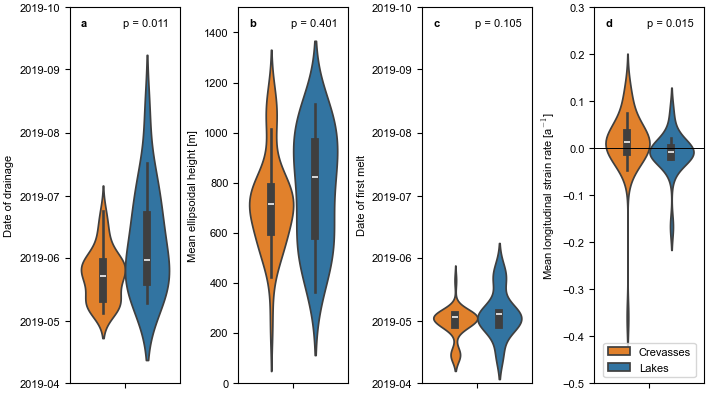

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

def compare_columns(col1, col2):

    # Combine with nicer labels
    df = pd.DataFrame({
        "value": pd.concat([col1, col2], ignore_index=True),
        "group": (["Crevasses"] * len(col1)) + (["Lakes"] * len(col2))
    })
    
    # Test difference
    stat, p = mannwhitneyu(col1, col2)

    return df, stat, p

# Set up plot
mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(ncols=4, nrows=1, figsize=(180*mm, 100*mm), layout='constrained') # 180 mm wide


# Date of max water
ax = axes[0]
df, stat, p = compare_columns(crevs_ponded['2019_max_water'], lakes['2019_max_water'])
sns.violinplot(
    hue="group", y="value", data=df, inner="box", legend=False,
    palette={"Crevasses": "tab:orange", "Lakes": "tab:blue"}, ax=ax
)
# ax.legend(title=None)
add_panel_label(ax, 'a', loc='top left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'p = {p:.3f}', loc='top right', offset=2*mm, weight='normal', color='k')
ax.set_ylabel("Date of drainage")
ax.set_ylim(datetime(2019, 4, 1), datetime(2019, 10, 1))

# Mean elevation
ax = axes[1]
df, stat, p = compare_columns(crevs_ponded['mean_h'], lakes['mean_h'])
sns.violinplot(
    hue="group", y="value", data=df, inner="box", legend=False,
    palette={"Crevasses": "tab:orange", "Lakes": "tab:blue"}, ax=ax
)
# ax.legend(title=None)
add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'p = {p:.3f}', loc='top right', offset=2*mm, weight='normal', color='k')
ax.set_ylabel("Mean ellipsoidal height [m]")
ax.set_ylim(0, 1500)

# Date of first melt
ax = axes[2]
df, stat, p = compare_columns(crevs_ponded['earliest_melt'], lakes['earliest_melt'])
sns.violinplot(
    hue="group", y="value", data=df, inner="box", legend=False,
    palette={"Crevasses": "tab:orange", "Lakes": "tab:blue"}, ax=ax
)
# ax.legend(title=None)
add_panel_label(ax, 'c', loc='top left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'p = {p:.3f}', loc='top right', offset=2*mm, weight='normal', color='k')
ax.set_ylabel("Date of first melt")
# ax.set_yticklabels(ax.get_yticklabels(), rotation=90, rotation_mode='anchor', va='center', ha='center')
ax.set_ylim(datetime(2019, 4, 1), datetime(2019, 10, 1))

# Mean longitudinal principal strain
ax = axes[3]
df, stat, p = compare_columns(crevs_ponded['mean_elon'], lakes['mean_elon'])
sns.violinplot(
    hue="group", y="value", data=df, inner="box", legend=True,
    palette={"Crevasses": "tab:orange", "Lakes": "tab:blue"}, ax=ax
)
ax.legend(title=None, loc='lower center')
add_panel_label(ax, 'd', loc='top left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'p = {p:.3f}', loc='top right', offset=2*mm, weight='normal', color='k')
ax.set_ylabel(r"Mean longitudinal strain rate [a$^{-1}$]")
ax.axhline(0, color='k', lw=.7)
ax.set_ylim(-.5, .3)


# # Mean first principal strain
# ax = axes[1, 1]
# df, stat, p = compare_columns(crevs_ponded['mean_e1'], lakes['mean_e1'])
# sns.violinplot(
#     hue="group", y="value", data=df, inner="box", legend=False,
#     palette={"Crevasses": "tab:orange", "Lakes": "tab:blue"}, ax=ax
# )
# # ax.legend(title=None)
# add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')
# add_panel_label(ax, f'    p = {p:.3f}', loc='top left', offset=2*mm, weight='normal', color='k')
# ax.set_ylabel(r"Mean first princiipal strain rate [a$^{-1}$]")
# ax.axhline(0, color='k', lw=.7)

# # Mean second principal strain
# ax = axes[1, 2]
# df, stat, p = compare_columns(crevs_ponded['mean_e2'], lakes['mean_e2'])
# sns.violinplot(
#     hue="group", y="value", data=df, inner="box", legend=False,
#     palette={"Crevasses": "tab:orange", "Lakes": "tab:blue"}, ax=ax
# )
# # ax.legend(title=None)
# add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')
# add_panel_label(ax, f'    p = {p:.3f}', loc='top left', offset=2*mm, weight='normal', color='k')
# ax.set_ylabel(r"Mean second princiipal strain rate [a$^{-1}$]")
# ax.axhline(0, color='k', lw=.7)

plt.savefig('../figures/figure_S4.jpg', dpi=600)
plt.savefig('../figures/figure_S4.pdf', dpi=300)

plt.show()


## Density plots comparing crevasses and lakes

Compare the two datasets and assess difference:

In [12]:
def day_to_date_str(day, year=None):
    """Convert day-of-year to readable date (default year = 2000 to avoid leap years)."""
    if year is None:
        year = 2000
    return (datetime(year, 1, 1) + pd.Timedelta(days=int(day)-1)).strftime("%b-%d")

def summarize(series, mean_std=True, is_date=False):
    """Return summary string depending on distribution and dtype."""
    if mean_std:  # normal
        mean, std = series.mean(), series.std(ddof=1)
        if is_date:
            return f"{day_to_date_str(round(mean))} ± {std:.1f} days"
        return f"{mean:.3f} ± {std:.3f}"
    else:  # non-normal
        median = np.median(series)
        iqr = np.percentile(series, 75) - np.percentile(series, 25)
        if is_date:
            return f"{day_to_date_str(round(median))} (IQR {iqr:.1f} days)"
        return f"{median:.3f} (IQR {iqr:.3f})"

def compare_columns(col1: pd.Series, col2: pd.Series, alpha=0.05):
    c1, c2 = col1.dropna(), col2.dropna()

    # Detect datetime
    is_date = False
    if np.issubdtype(c1.dtype, np.datetime64) and np.issubdtype(c2.dtype, np.datetime64):
        c1, c2 = c1.dt.dayofyear, c2.dt.dayofyear
        is_date = True

    # Normality check
    norm1 = stats.shapiro(c1).pvalue > alpha
    norm2 = stats.shapiro(c2).pvalue > alpha
    both_normal = norm1 and norm2

    if both_normal:
        test_name = "Welch’s t-test"
        stat, p = stats.ttest_ind(c1, c2, equal_var=False)
    else:
        test_name = "Mann-Whitney U"
        stat, p = stats.mannwhitneyu(c1, c2, alternative='two-sided')

    return {
        "col1": summarize(c1, both_normal, is_date),
        "col2": summarize(c2, both_normal, is_date),
        "test": test_name,
        "statistic": stat,
        "p_value": p,
        "significant": p < alpha
    }

# var = '2019_max_water'
# var = 'mean_e1'
# var = 'mean_e2'
var = 'mean_elon'
# var = 'mean_h'

compare_columns(crevs_ponded[var], lakes[var])

{'col1': '0.014 (IQR 0.041)',
 'col2': '-0.009 (IQR 0.018)',
 'test': 'Mann-Whitney U',
 'statistic': 556.0,
 'p_value': 0.014751029139745577,
 'significant': True}

(np.float64(18017.0), np.float64(18109.0))

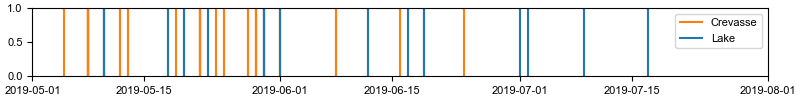

In [137]:
plt.close()
fig, ax = plt.subplots(figsize=(8,1))

first=True
for d in crevs_ponded['2019_max_water'].values:
    if first==True:
        label='Crevasse'
    else:
        label=None
    ax.axvline(d, color='tab:orange', label=label)
    first=False

first=True
for d in lakes['2019_max_water'].values:
    if first==True:
        label='Lake'
    else:
        label=None
    ax.axvline(d, color='tab:blue', label=label)
    first=False

ax.legend()

ax.set_xlim(pd.to_datetime('2019-05-01'), pd.to_datetime('2019-08-01'))


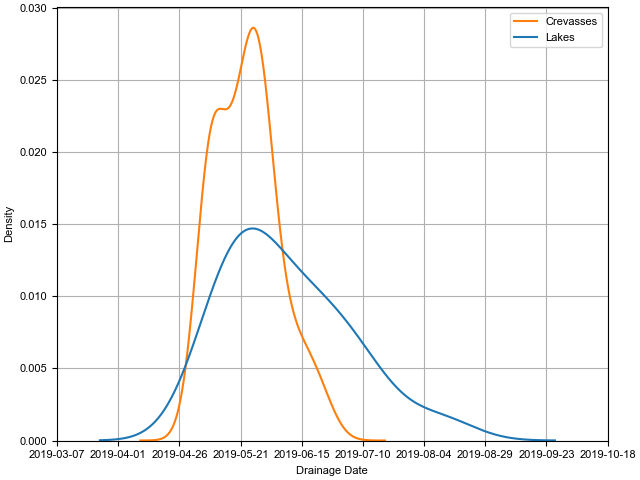

In [156]:
plt.close()
fig, ax = plt.subplots()

crevs_ponded['2019_max_water_num'] = crevs_ponded['2019_max_water'].map(pd.Timestamp.toordinal)
crevs_ponded['2019_max_water_num'].plot.kde(ax=ax, label='Crevasses', color='tab:orange')

lakes['2019_max_water_num'] = lakes['2019_max_water'].map(pd.Timestamp.toordinal)
lakes['2019_max_water_num'].plot.kde(ax=ax, label='Lakes', color='tab:blue')

ax.grid()
ax.legend()
ax.set_xlabel('Drainage Date')
ax.set_ylim(0, None)

# rename the xticks with labels
x_ticks = ax.get_xticks()
ax.set_xticks(x_ticks[::1])
xlabels = [datetime.datetime.fromordinal(int(x)).strftime('%Y-%m-%d') for x in x_ticks[::1]]
ax.set_xticklabels(xlabels)

plt.show()
# plt.xticks(crevs_ponded['2019_max_water_num'][::len(crevs_ponded)//5], crevs_ponded['2019_max_water'][::len(crevs_ponded)//5].dt.date, rotation=45)

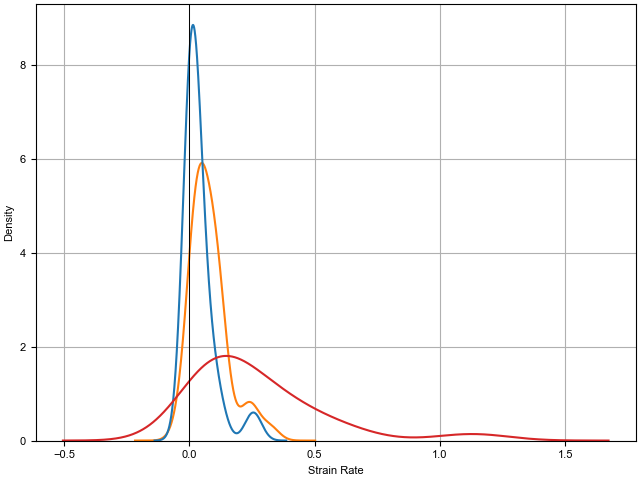

In [171]:
plt.close()
fig, ax = plt.subplots()

crevs_ponded['mean_e1'].plot.kde(ax=ax, label='Ponded Crevasses', color='tab:orange')

lakes['mean_e1'].plot.kde(ax=ax, label='Lakes', color='tab:blue')

crevs_empty['mean_e1'].plot.kde(ax=ax, label='Empty Crevasses', color='tab:red')


ax.axvline(0, c='k', lw=.7)


ax.grid()
ax.set_xlabel('Strain Rate')
ax.set_ylim(0, None)

plt.show()

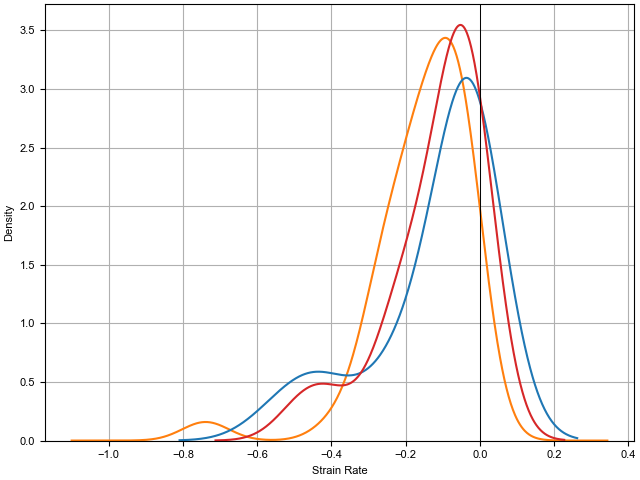

In [172]:
plt.close()
fig, ax = plt.subplots()

crevs_ponded['mean_e2'].plot.kde(ax=ax, label='Ponded Crevasses', color='tab:orange')
lakes['mean_e2'].plot.kde(ax=ax, label='Lakes', color='tab:blue')
crevs_empty['mean_e2'].plot.kde(ax=ax, label='Empty Crevasses', color='tab:red')

ax.axvline(0, c='k', lw=.7)


ax.grid()
ax.set_xlabel('Strain Rate')
ax.set_ylim(0, None)

plt.show()

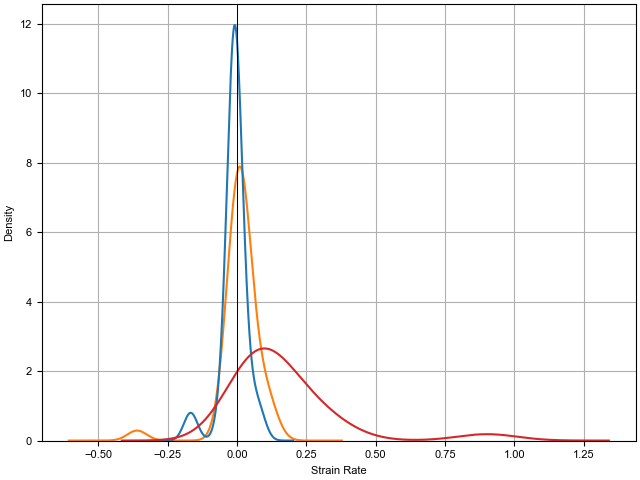

In [173]:
plt.close()
fig, ax = plt.subplots()

crevs_ponded['mean_elon'].plot.kde(ax=ax, label='Crevasses', color='tab:orange')
lakes['mean_elon'].plot.kde(ax=ax, label='Lakes', color='tab:blue')
crevs_empty['mean_elon'].plot.kde(ax=ax, label='Empty Crevasses', color='tab:red')

ax.axvline(0, c='k', lw=.7)


ax.grid()
ax.set_xlabel('Strain Rate')
ax.set_ylim(0, None)

plt.show()